In [1]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.5) # "talk"
from matplotlib.animation import FuncAnimation

ANIMATION=True
PLOT_FLUX=True

In [2]:
DT_all=0.01#6
Tend_all=0.3
mx=81
FLUX_TYPE=2


if(FLUX_TYPE==1):
    Flux_c=1.
    Flux_cv=np.zeros((1,mx))
    Flux_cv[:]=1.
    Flux_cv[0,3:int(mx/2.)-2]=2.
elif(FLUX_TYPE==2):
    nF=int(mx/2)
    shift=3

    Flux_cv=np.zeros((1,mx))
    Flux_cv[0,:]=1.
    Flux_cv[0,(0+shift):(nF-shift)]=2.
elif(FLUX_TYPE==3):
    pass
else:
    error()

CFL max = 1.539; CFL min = 0.81
Solving Advection1D by using MPRK2
Mass ini = 0.9999999999999999 and mass end = 1.0


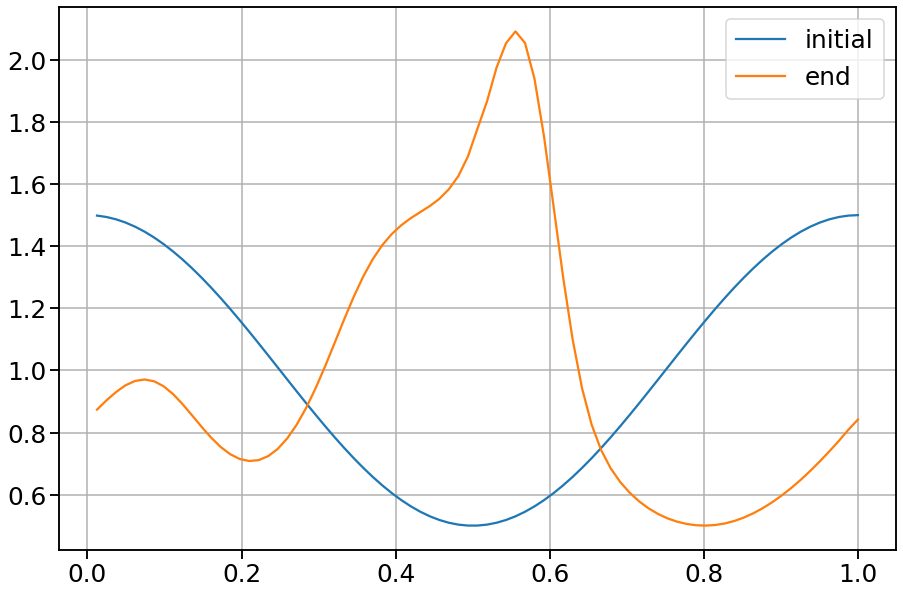

In [3]:
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'Flux_name':'FVStagVanLeer-k=1/3'}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection1D',pde_problem_setup)#('Navier-Stokes2D')

if(FLUX_TYPE==2):
    x_coord=problem_setup['context']['x_coord']
    #Flux_cv[0,(0):(nF)]=1.+np.sin(2*np.pi*x_coord[(0):(nF)])
    Flux_cv[0,(0):(nF)]=1.+0.9*np.exp(-((x_coord[(0):(nF)]-x_coord[nF//2-3])**2)*1.25*mx)
if(FLUX_TYPE==3):
    Flux_cv[0,:]=x_coord[:]
    
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
#solver.set_method('RK4')
solver.set_method('MPRK2')
#solver.set_method('MPRK2-RK3SSPHig')
solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow})

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=DT_all    
problem_setup['T_DURATION']['end']=Tend_all
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u=solver.get_trajectory()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()


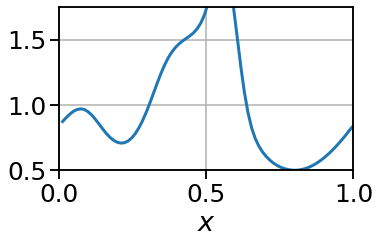

In [4]:
if(ANIMATION):
    fig = plt.figure()
    ax = plt.axes(xlim=(0, 1), ylim=(0.5, 1.75))
    line, = ax.plot([], [], lw=3)
    plt.grid('both')
    plt.xlabel(r'$x$')
    plt.tight_layout()
    frames=u.shape[1]

    def init():
        line.set_data([], [])
        return line,
    def animate(i):
        x = x_coord
        y = np.squeeze(unvec(u[:,i],problem_setup['context']))
        line.set_data(x, y)
        return line,

    anim = FuncAnimation(fig, animate, init_func=init,
                                   frames=frames, interval=1, blit=True)


    anim.save('mrk_mr.gif', writer='imagemagick')

CFL max = 0.7695; CFL min = 0.405
Solving Advection1D by using RK2a
Using a dt = 0.005
Mass ini = 0.9999999999999999 and mass end = 1.0


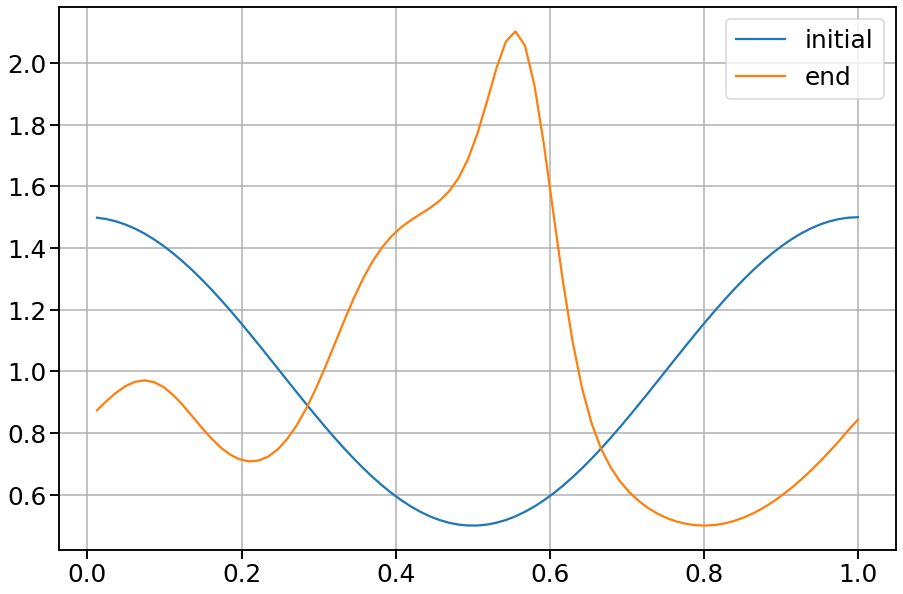

In [5]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'Flux_name':'FVStagVanLeer-k=1/3'}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
#solver.set_method('RK4')
solver.set_method('RK2a')
#solver.set_method('MPRK2-RK3SSPHig')
solver.set_rhs(rhs_e)

problem_setup['DT']=DT_all*0.5
problem_setup['T_DURATION']['end']=Tend_all
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))
solver.solve()

t,u=solver.get_trajectory()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()


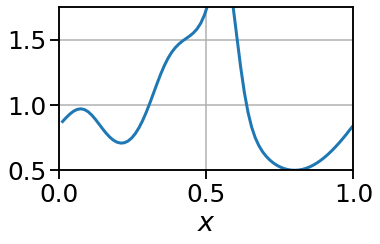

In [6]:
if(ANIMATION):
    fig = plt.figure()
    ax = plt.axes(xlim=(0, 1), ylim=(0.5, 1.75))
    line, = ax.plot([], [], lw=3)
    plt.grid('both')
    plt.xlabel(r'$x$')
    plt.tight_layout()
    frames=u.shape[1]

    def init():
        line.set_data([], [])
        return line,
    def animate(i):
        x = x_coord
        y = np.squeeze(unvec(u[:,i],problem_setup['context']))
        line.set_data(x, y)
        return line,

    anim = FuncAnimation(fig, animate, init_func=init,
                                   frames=frames, interval=1, blit=True)


    anim.save('mrk_sr.gif', writer='imagemagick')

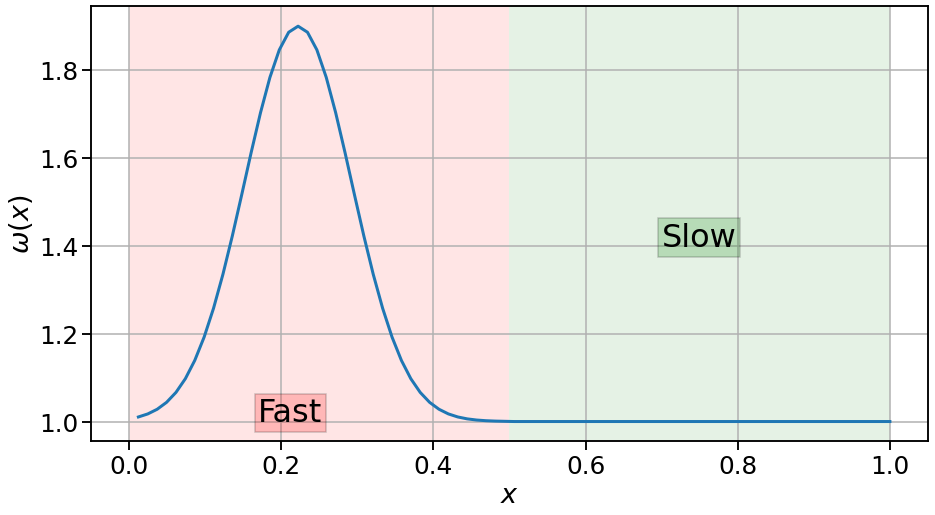

In [14]:
if(PLOT_FLUX):
    fig = plt.figure(figsize=(15, 8))
    plt.plot(x_coord,np.squeeze(Flux_cv),lw=3)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$\omega(x)$')
    plt.grid('both')
    ax_list = fig.axes
    ax_list[0].axvspan(0, 0.5, facecolor='red', alpha=0.1)
    FS=32
    plt.text(0.17, 1, 'Fast', fontsize=FS,bbox=dict(facecolor='red', alpha=0.2))
    ax_list[0].axvspan(0.5, 1., facecolor='green', alpha=0.1)
    plt.text(0.7, 1.4, 'Slow', fontsize=FS,bbox=dict(facecolor='green', alpha=0.2))
    plt.show()